# Real Estate Taxonomy Data Exploration

This notebook explores the structured real estate terminology and the dataset extracted from `rets_property.sql`.

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

## 1. Analyze Sample Listings

Total Sample Listings: 1000
Average Remark Length: 406.99 characters


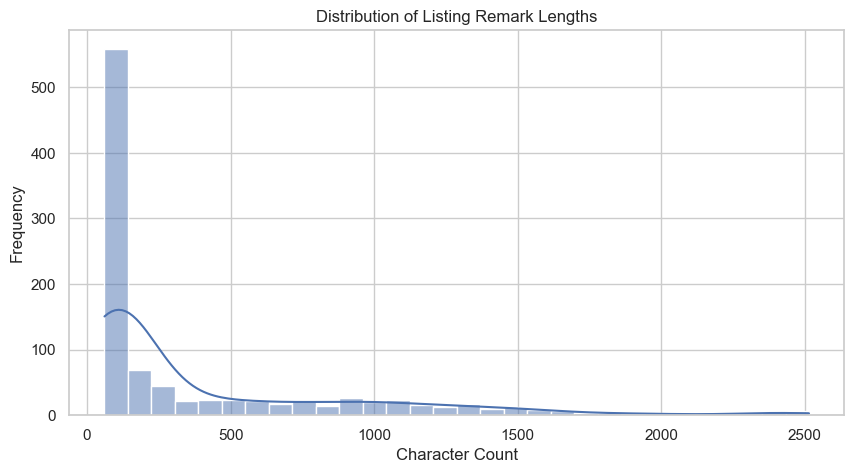

In [2]:
df = pd.read_csv('../data/processed/sample_listing.csv')
df['remark_length'] = df['remarks'].apply(lambda x: len(str(x)))

print(f"Total Sample Listings: {len(df)}")
print(f"Average Remark Length: {df['remark_length'].mean():.2f} characters")

plt.figure(figsize=(10, 5))
sns.histplot(df['remark_length'], bins=30, kde=True)
plt.title('Distribution of Listing Remark Lengths')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.show()

## 2. Analyze the Taxonomy

C:\Users\desai\AppData\Local\Temp\ipykernel_29804\3484433497.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(category_counts.values()), y=list(category_counts.keys()), palette='viridis')


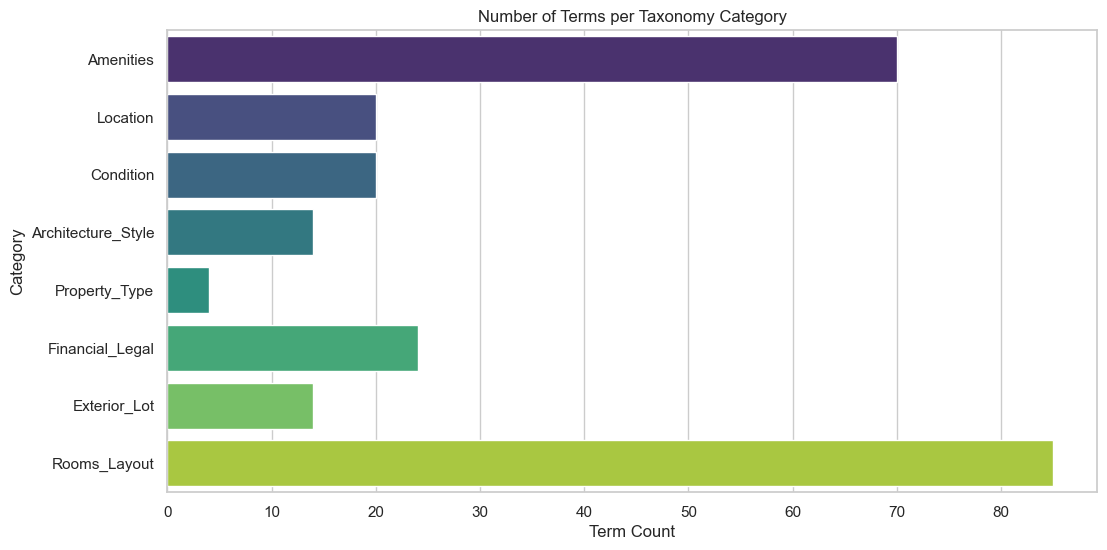

Total terms categorized: 251


In [3]:
with open('../data/processed/taxonomy.json', 'r') as f:
    taxonomy = json.load(f)

from collections import Counter
category_counts = dict(Counter(item['category'] for item in taxonomy.get('terms', [])))

plt.figure(figsize=(12, 6))
sns.barplot(x=list(category_counts.values()), y=list(category_counts.keys()), palette='viridis')
plt.title('Number of Terms per Taxonomy Category')
plt.xlabel('Term Count')
plt.ylabel('Category')
plt.show()

total_terms = sum(category_counts.values())
print(f"Total terms categorized: {total_terms}")